# COVID-19 in Newfoundland and Labrador

This [Jupyter Lab](https://jupyter.org/) notebook analyzes a data set on COVID-19 cases in Canada. The intention is to test the effectiveness of the [Gompertz function](https://en.wikipedia.org/wiki/Gompertz_function) in describing and predicting the total number of COVID-19 cases, specifically in Newfoundland and Labrador.

# Introduction

The **Gompertz function** is defined by Wikipedia as, "a sigmoid function which describes growth as being slowest at the start and end of a given time period." It is commonly used in modelling many forms of biological growth, including the growth of animals and plants in size, the growth of tumour cells in the body and so on. Can the Gompertz function also describe and predict the growth of COVID-19?

To answer this question, we will create a model centered around the Gompertz function, using it to fit a curve to a record of the total number of COVID-19 cases in the province. From evaluating the accuracy of the results, we should be able to get a good impression of the effectiveness of the Gompertz function in modelling the growth of the pandemic.

In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime
import numpy as np
import math
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.optimize import curve_fit
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.api import add_constant
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("https://health-infobase.canada.ca/src/data/covidLive/covid19-download.csv")
# Convert totalcases to a number, eliminating any NA results created in the process.
data['totalcases'] = pd.to_numeric(data['totalcases'],errors="coerce")
data = data.dropna(subset='totalcases')
# Convert date from a string into a proper datetime.
data['date'] = pd.to_datetime(data['date'])
# Narrow the data set down to fields relevant to Newfoundland and Labrador.
data = data[data['prname'] == "Newfoundland and Labrador"]
# To avoid instances of division by zero, we'll only consider case numbers
# greater than zero.
data = data[data['totalcases'] != 0]

Now that the basic data tidying is complete, it's possible to proceed with defining the Gompertz function itself. A **training** and **test** data set will also be created by partitioning the original data set; 80% of the records will be used for training the model and the remaining 20% will be used to test its effectiveness.

# Training Data

In [193]:
# Define the Gompertz function.
def gompertz(x, A, B, C):
    return A * np.exp(-B * np.exp(-C * x))

# Randomly split the data into training (80%) and testing (20%) sets.
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Split into X and y for both training and testing sets.
X_train = train_data.drop('totalcases', axis=1)
y_train = train_data['totalcases']
X_test = test_data.drop('totalcases', axis=1)
y_test = test_data['totalcases']

# Ensure that the data is reset to maintain consistent indexing.
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)    

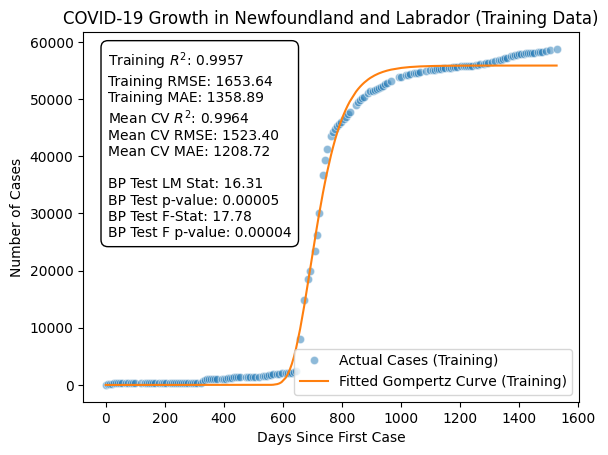

In [194]:
# Add 'days' column to X_train and X_test
X_train['days'] = (X_train['date'] - X_train['date'].min()).dt.days
X_test['days'] = (X_test['date'] - X_test['date'].min()).dt.days

# Initial guess for Gompertz curve parameters
initial_guess = [y_train.max(), 1, 0.01]

# K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []
cv_mae_scores = []

for train_index, test_index in kf.split(X_train):
    train_days, test_days = X_train['days'].iloc[train_index], X_train['days'].iloc[test_index]
    train_cases, test_cases = y_train.iloc[train_index], y_train.iloc[test_index]

    try:
        params, covariance = curve_fit(gompertz, train_days, train_cases, p0=initial_guess, maxfev=10000)
        predicted_cases = gompertz(test_days, *params)
        
        residuals = test_cases - predicted_cases
        ss_total = np.sum((test_cases - np.mean(test_cases)) ** 2)
        ss_residual = np.sum(residuals ** 2)
        r_squared = 1 - (ss_residual / ss_total)
        rmse = np.sqrt(mean_squared_error(test_cases, predicted_cases))
        mae = mean_absolute_error(test_cases, predicted_cases)
        
        cv_r2_scores.append(r_squared)
        cv_rmse_scores.append(rmse)
        cv_mae_scores.append(mae)
    
    except RuntimeError:
        print("Curve fitting failed for this fold")
        continue

# Calculate mean cross-validation metrics
mean_cv_r2 = np.mean(cv_r2_scores)
mean_cv_rmse = np.mean(cv_rmse_scores)
mean_cv_mae = np.mean(cv_mae_scores)

# Fit Gompertz curve to the training data
params_train, covariance_train = curve_fit(gompertz, X_train['days'], y_train, p0=initial_guess, maxfev=10000)

# Calculate fitted values and residuals for the training data
X_train['fitted_cases'] = gompertz(X_train['days'], *params_train)
residuals_train = y_train - X_train['fitted_cases']

# Fit Gompertz curve to the test data
params_test, covariance_test = curve_fit(gompertz, X_test['days'], y_test, p0=initial_guess, maxfev=10000)
X_test['fitted_cases'] = gompertz(X_test['days'], *params_test)

# Calculate residuals for the test data
residuals_test = y_test - X_test['fitted_cases']

# Calculate R-squared, RMSE, and MAE for the test data
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_residual = np.sum(residuals_test**2)
r_squared = 1 - (ss_residual / ss_total)
rmse = np.sqrt(mean_squared_error(y_test, X_test['fitted_cases']))
mae = mean_absolute_error(y_test, X_test['fitted_cases'])

# Perform Breusch-Pagan test for heteroscedasticity (training data)
X_with_constant = add_constant(X_train['days'])  # Add constant to predictor
bp_test = het_breuschpagan(residuals_train, X_with_constant)
bp_test_results = {
    "Lagrange Multiplier Statistic": bp_test[0],
    "p-value": bp_test[1],
    "F-statistic": bp_test[2],
    "F-test p-value": bp_test[3],
}

# Plot actual cases and fitted Gompertz curve for the training data
sns.lineplot(x=X_train['days'], y=y_train, label='Actual Cases (Training)', color='tab:blue', marker='o', linestyle='None', alpha=0.5)
sns.lineplot(x=X_train['days'], y=X_train['fitted_cases'], label='Fitted Gompertz Curve (Training)', color='tab:orange')

plt.title("COVID-19 Growth in Newfoundland and Labrador (Training Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)

# Combine performance metrics and Breusch-Pagan test results into a single text block
metrics_text = (
    f"Training $R^2$: {r_squared:.4f}\n"
    f"Training RMSE: {rmse:.2f}\n"
    f"Training MAE: {mae:.2f}\n"
    f"Mean CV $R^2$: {mean_cv_r2:.4f}\n"
    f"Mean CV RMSE: {mean_cv_rmse:.2f}\n"
    f"Mean CV MAE: {mean_cv_mae:.2f}\n\n"
    f"BP Test LM Stat: {bp_test[0]:.2f}\n"
    f"BP Test p-value: {bp_test[1]:.5f}\n"
    f"BP Test F-Stat: {bp_test[2]:.2f}\n"
    f"BP Test F p-value: {bp_test[3]:.5f}"
)

# Add the textbox with a border around it
plt.gca().text(
    0.05, 0.95, metrics_text,
    transform=plt.gca().transAxes,  # Relative to the axes
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')  # Box properties
)
plt.show()

A few observations may be made about the model's performance in training. The $R^2$ value is high, meaning that the model explains a large percentage of the variability seen in the training data. The RMSE (root mean squared error) indicates how much the predictions made by the Gompertz model deviate from actual case numbers, on average. The MAE indicates by how many cases the predictions were off by, on average. In this case both the RMSE and MAE are low (in comparison to the scale of total case numbers).

The mean CV $R^2$, mean CV $RMSE$ and mean CV $MAE$ are all the results of cross-validation tests; they indicate the model's performance when tested against unseen data. The cross-validation metrics are all very close to the values of their respective training metrics, indicating that the model "generalizes well and is not overfitting."<sup>1</sup>

Finally, the metrics labelled with "BP" are all related to the **Breusch-Pagan** test for heteroscedasticity. In this case the BP test $p$-value and F $p$-value are both extremely low, suggesting that the model's variance is not constant. This could potentially indicate "where the model's predictions systematically deviate from the actual data."<sup>1</sup>


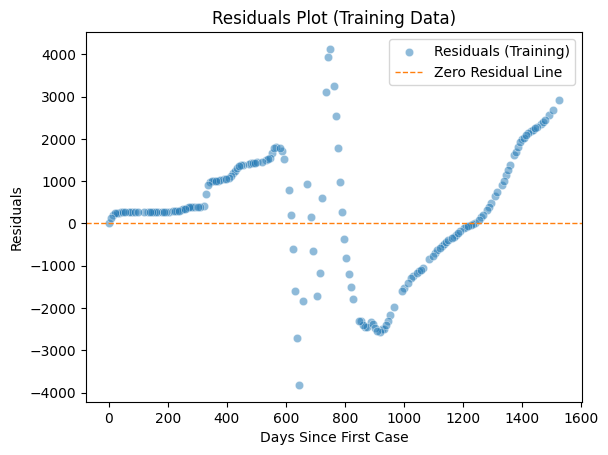

In [195]:
# Plot residuals for the training data
sns.scatterplot(x=X_train['days'], y=residuals_train, color='tab:blue', alpha=0.5, label='Residuals (Training)')
plt.axhline(0, color='tab:orange', linestyle='--', linewidth=1, label='Zero Residual Line')
plt.title("Residuals Plot (Training Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Residuals")
plt.legend()
plt.grid(False)
plt.show()


There is clearly a pattern in the distribution of the residuals; they are not randomly distributed. During the early phase of the pandemic, from about 0-400 days, the residuals are tightly clustered about the zero line, indicating a good fit by the model for this phase. The middle phase, defined as days 400-800, demonstrate the widest amount of spread in the residuals about the zero line. This suggests that the Gompertz model "may have struggled to capture the dynamics of the middle phase, possibly due to irregularities in case growth, such as a sudden increase or decrease caused by external factors (e.g., policy changes or reporting delays)."<sup>1</sup> The residuals in the late phase of the pandemic (days 800 onwards) exhibit a "fanning out" of the residuals across the zero line; the spread increases as time increases. This indicates heteroscedasticity; the models errors grow as the total number of cases grow. Overall, the model "tends to underpredict large case counts and overpredict during plateau phases."<sup>1</sup>

# Test Data

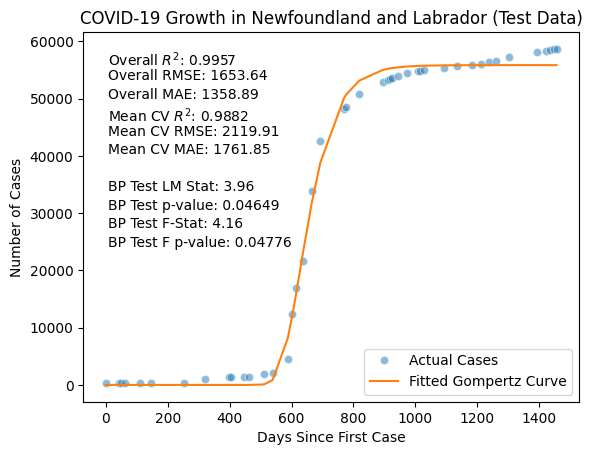

In [196]:
# Add 'days' column to X_test
X_test['days'] = (X_test['date'] - X_test['date'].min()).dt.days

# Initial guess for Gompertz curve parameters
initial_guess = [y_test.max(), 1, 0.01]

# Gompertz function definition (ensure it's defined before using it)
def gompertz(x, a, b, c):
    return a * np.exp(-b * np.exp(-c * x))

# K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []
cv_mae_scores = []

for train_index, test_index in kf.split(X_test):
    train_days, test_days = X_test['days'].iloc[train_index], X_test['days'].iloc[test_index]
    train_cases, test_cases = y_test.iloc[train_index], y_test.iloc[test_index]

    try:
        params, covariance = curve_fit(gompertz, train_days, train_cases, p0=initial_guess, maxfev=10000)
        
        predicted_cases = gompertz(test_days, *params)
        
        residuals = test_cases - predicted_cases
        ss_total = np.sum((test_cases - np.mean(test_cases)) ** 2)
        ss_residual = np.sum(residuals ** 2)
        r_squared = 1 - (ss_residual / ss_total)
        rmse = np.sqrt(mean_squared_error(test_cases, predicted_cases))
        mae = mean_absolute_error(test_cases, predicted_cases)
        
        cv_r2_scores.append(r_squared)
        cv_rmse_scores.append(rmse)
        cv_mae_scores.append(mae)
    
    except RuntimeError:
        print("Curve fitting failed for this fold")
        continue

# Calculate mean cross-validation metrics
mean_cv_r2 = np.mean(cv_r2_scores)
mean_cv_rmse = np.mean(cv_rmse_scores)
mean_cv_mae = np.mean(cv_mae_scores)

# Fit Gompertz curve to the full test data
params, covariance = curve_fit(gompertz, X_test['days'], y_test, p0=initial_guess, maxfev=10000)
X_test['fitted_cases'] = gompertz(X_test['days'], *params)

# Calculate residuals
residuals = y_test - X_test['fitted_cases']

# Calculate R-squared, RMSE, and MAE for the test data
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_residual = np.sum(residuals**2)
r_squared = 1 - (ss_residual / ss_total)
rmse = np.sqrt(mean_squared_error(y_test, X_test['fitted_cases']))
mae = mean_absolute_error(y_test, X_test['fitted_cases'])

# Perform Breusch-Pagan test for heteroscedasticity
X_with_constant = add_constant(X_test['days'])  # Add constant to predictor
bp_test = het_breuschpagan(residuals, X_with_constant)
bp_test_results = {
    "Lagrange Multiplier Statistic": bp_test[0],
    "p-value": bp_test[1],
    "F-statistic": bp_test[2],
    "F-test p-value": bp_test[3],
}

# Plot actual cases and fitted Gompertz curve
sns.lineplot(x=X_test['days'], y=y_test, label='Actual Cases', color='tab:blue', marker='o', linestyle='None', alpha=0.5)
sns.lineplot(x=X_test['days'], y=X_test['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')

plt.title("COVID-19 Growth in Newfoundland and Labrador (Test Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)

# Display performance metrics and Breusch-Pagan test results on the plot
plt.text(0.05, 0.95, f"Overall $R^2$: {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"Overall RMSE: {rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.85, f"Overall MAE: {mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.80, f"Mean CV $R^2$: {mean_cv_r2:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.75, f"Mean CV RMSE: {mean_cv_rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.70, f"Mean CV MAE: {mean_cv_mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# Add Breusch-Pagan test results to the plot
plt.text(0.05, 0.60, f"BP Test LM Stat: {bp_test[0]:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.55, f"BP Test p-value: {bp_test[1]:.5f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.50, f"BP Test F-Stat: {bp_test[2]:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.45, f"BP Test F p-value: {bp_test[3]:.5f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.show()


The overall $R^2$ value is high in this case as well, indicating that the model explains the variance seen in the test data set to a high percentage. The overall $RMSE$ and $MAE$ are also quite low in comparison to the scale of total case numbers, indicating that the errors that do exist are moderate. Since $RMSE > MAE$, we can conclude that there are a few large errors in the predictions.

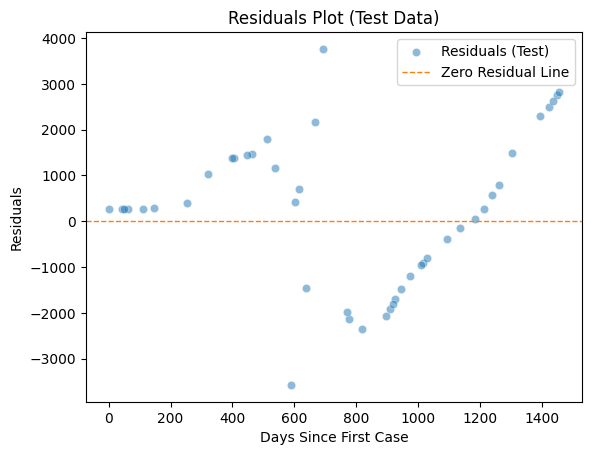

In [197]:
# Plot residuals for the test data
sns.scatterplot(x=X_test['days'], y=residuals_test, color='tab:blue', alpha=0.5, label='Residuals (Test)')
plt.axhline(0, color='tab:orange', linestyle='--', linewidth=1, label='Zero Residual Line')
plt.title("Residuals Plot (Test Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Residuals")
plt.legend()
plt.grid(False)
plt.show()

The residuals plot for the test data show that the residuals fluctuate about the zero line, but once again, there are noticeable patterns. From days 0 to ~600 the residuals are relatively close to zero, suggesting a good fit by the model at this phase. In the transition phase from days ~600 to ~1000, there are much larger residuals and more variability. Both positive and negative residuals are present, indicating that the model both overpredicts **and** underpredicts during this phase. All of this "reflects the non-linear and dynamic nature of case growth during the transition phase, which the Gompertz model struggles to fully capture."<sup>1</sup>

We have trained the model and evaluated its performance against a subset of our total data set. We have also evaluated the model's performance against a test data set, representing new and unseen data. We are now ready to proceed to the final step; applying the Gompertz model to the complete data set.

# Complete Data

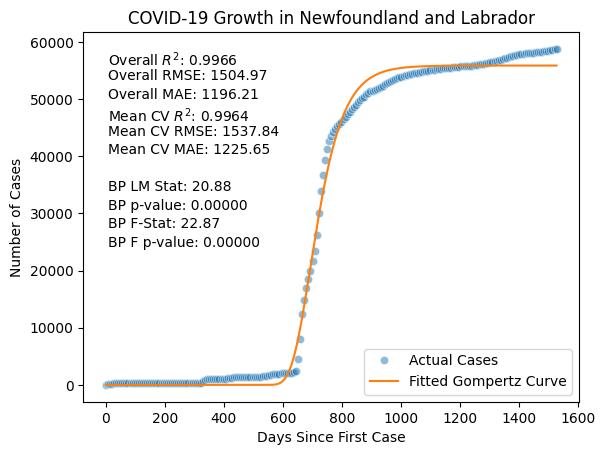

In [198]:
# Calculate days since the first case
data['days'] = (data['date'] - data['date'].min()).dt.days

# Define the Gompertz function
def gompertz(t, A, B, C):
    return A * np.exp(-B * np.exp(-C * t))

# Initial guess for Gompertz curve parameters
initial_guess = [data['totalcases'].max(), 1, 0.01]

# Parameter bounds to prevent overflow
parameter_bounds = (
    [0, 0, 0],  # Lower bounds: A, B, C >= 0
    [np.inf, np.inf, 1]  # Upper bounds: A, B unbounded, C <= 1
)

# K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []
cv_mae_scores = []

for train_index, test_index in kf.split(data):
    train_data = data.iloc[train_index]
    test_data = data.iloc[test_index].copy()  # Explicitly create a copy to avoid SettingWithCopyWarning

    try:
        # Fit the Gompertz curve to the training data
        params, covariance = curve_fit(
            gompertz, 
            train_data['days'], 
            train_data['totalcases'], 
            p0=initial_guess, 
            bounds=parameter_bounds, 
            maxfev=10000
        )
        
        # Generate predictions on the test data
        test_data['fitted_cases'] = gompertz(test_data['days'], *params)
        
        # Calculate residuals
        residuals = test_data['totalcases'] - test_data['fitted_cases']

        # Calculate performance metrics
        ss_total = np.sum((test_data['totalcases'] - np.mean(test_data['totalcases'])) ** 2)
        ss_residual = np.sum(residuals ** 2)
        r_squared = 1 - (ss_residual / ss_total)
        rmse = np.sqrt(mean_squared_error(test_data['totalcases'], test_data['fitted_cases']))
        mae = mean_absolute_error(test_data['totalcases'], test_data['fitted_cases'])

        # Append metrics to lists
        cv_r2_scores.append(r_squared)
        cv_rmse_scores.append(rmse)
        cv_mae_scores.append(mae)
    
    except RuntimeError:
        print("Curve fitting failed for this fold")
        continue

# Calculate mean cross-validation metrics
mean_cv_r2 = np.mean(cv_r2_scores)
mean_cv_rmse = np.mean(cv_rmse_scores)
mean_cv_mae = np.mean(cv_mae_scores)

# Fit Gompertz curve to the entire dataset
params, covariance = curve_fit(
    gompertz, 
    data['days'], 
    data['totalcases'], 
    p0=initial_guess, 
    bounds=parameter_bounds, 
    maxfev=10000
)
data['fitted_cases'] = gompertz(data['days'], *params)

# Recalculate residuals for the full dataset
residuals = data['totalcases'] - data['fitted_cases']

# Calculate R-squared
ss_total = np.sum((data['totalcases'] - np.mean(data['totalcases'])) ** 2)
ss_residual = np.sum(residuals ** 2)
r_squared = 1 - (ss_residual / ss_total)

# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(data['totalcases'], data['fitted_cases']))
mae = mean_absolute_error(data['totalcases'], data['fitted_cases'])

# Perform Breusch-Pagan test for heteroscedasticity
X_with_constant = add_constant(data['days'])  # Add constant to predictor
bp_test = het_breuschpagan(residuals, X_with_constant)
bp_test_results = {
    "Lagrange Multiplier Statistic": bp_test[0],
    "p-value": bp_test[1],
    "F-statistic": bp_test[2],
    "F-test p-value": bp_test[3],
}

# Plot actual case numbers and fitted Gompertz curve
sns.lineplot(x=data['days'], y=data['totalcases'], label='Actual Cases', color='tab:blue', marker='o', linestyle='None', alpha=0.5)
sns.lineplot(x=data['days'], y=data['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')

plt.title("COVID-19 Growth in Newfoundland and Labrador")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)

# Display performance metrics and Breusch-Pagan test results on the plot
plt.text(0.05, 0.95, f"Overall $R^2$: {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"Overall RMSE: {rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.85, f"Overall MAE: {mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.80, f"Mean CV $R^2$: {mean_cv_r2:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.75, f"Mean CV RMSE: {mean_cv_rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.70, f"Mean CV MAE: {mean_cv_mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# Add Breusch-Pagan test results to the plot
plt.text(0.05, 0.60, f"BP LM Stat: {bp_test[0]:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.55, f"BP p-value: {bp_test[1]:.5f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.50, f"BP F-Stat: {bp_test[2]:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.45, f"BP F p-value: {bp_test[3]:.5f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.show()


The overall $R^2$ value is very close to 1, indicating a good fit. The overall RMSE and MAE are both fairly low when the scale of total case numbers is taken into consideration. In addition, the cross-validation metrics were very close to that of the overall results, indicating that the model "generalizes well across different data splits.<sup>1</sup> However, the Breusch-Pagan results demonstrate **heteroscedasticity,** as the $p$-value and F $p$-value are both effectively zero. This suggests that the variance of the residuals increases or decreases systematically with the predictor variable (in this case, the number of days).

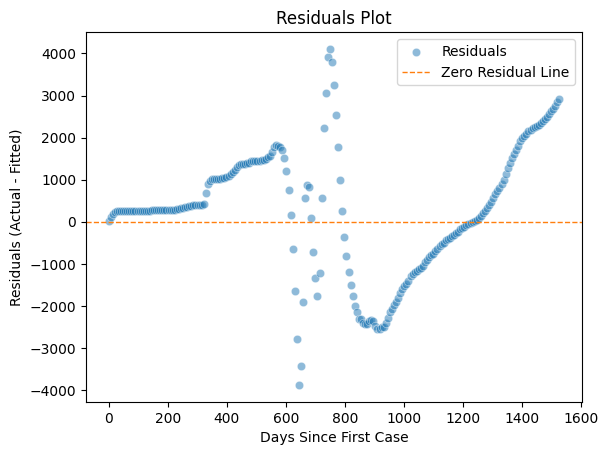

In [199]:
# Plot residuals for the entire dataset
sns.scatterplot(x=data['days'], y=residuals, color='tab:blue', alpha=0.5, label='Residuals')
plt.axhline(0, color='tab:orange', linestyle='--', linewidth=1, label='Zero Residual Line')
plt.title("Residuals Plot")
plt.xlabel("Days Since First Case")
plt.ylabel("Residuals (Actual - Fitted)")
plt.legend()
plt.grid(False)
plt.show()


# Can We Improve Upon the Model?

One way we could potentially address the issue of heteroscedasticity would be to try different transformations of the dependent variable (the total number of cases), in an attempt to determine if one such transformation would result in a better fit for the data. For example, here is a plot of the same data and the same fitted curve, but with a square root transformation applied to the dependent variable.

## Square Root Transformation

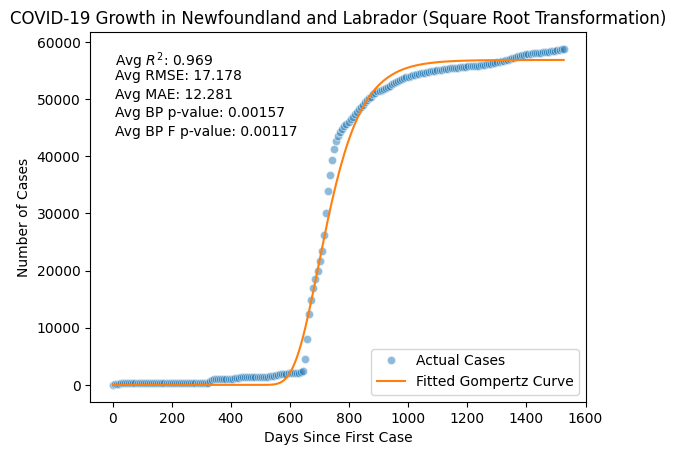

In [200]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Perform a square root transformation on the dependent variable.
data['sqrt_totalcases'] = np.sqrt(data['totalcases'])
data['days'] = (data['date'] - data['date'].min()).dt.days

# Initialize cross-validation and placeholders for metrics.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores, rmse_scores, mae_scores = [], [], []
bp_p_values, bp_f_p_values = [], []

# Cross-validation.
for train_index, test_index in kf.split(data):
    train_data = data.iloc[train_index]
    test_data = data.iloc[test_index].copy()  # Explicitly make a copy
    
    # Fit the Gompertz model on the training set.
    initial_guess = [np.sqrt(train_data['totalcases'].max()), 1, 0.01]
    params, _ = curve_fit(gompertz, train_data['days'], train_data['sqrt_totalcases'], p0=initial_guess)
    
    # Predict on the test set.
    test_data['fitted_sqrt_cases'] = gompertz(test_data['days'], *params)
    test_data['fitted_cases'] = test_data['fitted_sqrt_cases']**2
    test_data['residuals_sqrt'] = test_data['sqrt_totalcases'] - test_data['fitted_sqrt_cases']
    
    # Perform the Breusch-Pagan test for heteroscedasticity.
    exog = sm.add_constant(test_data['days'])  # Add constant for intercept in regression.
    bp_test = het_breuschpagan(test_data['residuals_sqrt'], exog)
    bp_p_values.append(bp_test[1])  # LM test p-value.
    bp_f_p_values.append(bp_test[3])  # F-statistic p-value.
    
    # Calculate performance metrics.
    ss_total = np.sum((test_data['sqrt_totalcases'] - np.mean(test_data['sqrt_totalcases']))**2)
    ss_residual = np.sum(test_data['residuals_sqrt']**2)
    r2_scores.append(1 - (ss_residual / ss_total))
    rmse_scores.append(np.sqrt(mean_squared_error(test_data['sqrt_totalcases'], test_data['fitted_sqrt_cases'])))
    mae_scores.append(mean_absolute_error(test_data['sqrt_totalcases'], test_data['fitted_sqrt_cases']))

# Aggregate metrics.
avg_r2 = np.mean(r2_scores)
avg_rmse = np.mean(rmse_scores)
avg_mae = np.mean(mae_scores)
avg_bp_p_value = np.mean(bp_p_values)
avg_bp_f_p_value = np.mean(bp_f_p_values)

# Fit model on the entire dataset for visualization.
params, _ = curve_fit(gompertz, data['days'], data['sqrt_totalcases'], p0=initial_guess)
data['fitted_sqrt_cases'] = gompertz(data['days'], *params)
data['fitted_cases'] = data['fitted_sqrt_cases']**2
data['residuals_sqrt'] = data['sqrt_totalcases'] - data['fitted_sqrt_cases']

# Main plot for Gompertz curve fitting.
sns.lineplot(x=data['days'], y=data['totalcases'], label='Actual Cases', color='tab:blue', marker='o', linestyle='None', alpha=0.5)
sns.lineplot(x=data['days'], y=data['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')
plt.title("COVID-19 Growth in Newfoundland and Labrador (Square Root Transformation)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")

# Add summary statistics and BP test results as text elements to the plot.
plt.text(x=0.05, y=0.95, s=f"Avg $R^2$: {avg_r2:.3f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(x=0.05, y=0.90, s=f"Avg RMSE: {avg_rmse:.3f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(x=0.05, y=0.85, s=f"Avg MAE: {avg_mae:.3f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(x=0.05, y=0.80, s=f"Avg BP p-value: {avg_bp_p_value:.5f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(x=0.05, y=0.75, s=f"Avg BP F p-value: {avg_bp_f_p_value:.5f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.legend()
plt.grid(False)
plt.show()


The high $R^2$ value once again demonstrates a good fit for the data after the square root transformation has been applied. The $RMSE$ and $MAE$ values are quite low in, indicating that on average, prediction errors are small. However, the results of the Breusch-Pagan test indicate values well below 0.05. This suggest significant evidence of heteroscedasticity in the residuals, but we should examine a residuals plot to be certain.

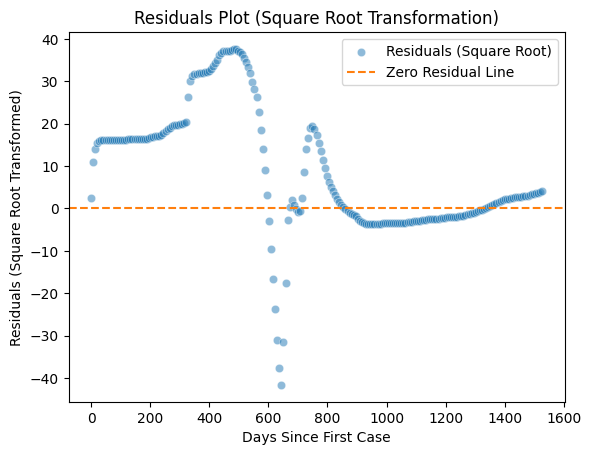

In [201]:
# Residuals plot (Square Root Transformation).
sns.scatterplot(x=data['days'], y=data['residuals_sqrt'], label='Residuals (Square Root)', color='tab:blue', alpha=0.5)
plt.axhline(0, color='tab:orange', linestyle='--', label='Zero Residual Line')
plt.title("Residuals Plot (Square Root Transformation)")
plt.xlabel("Days Since First Case")
plt.ylabel("Residuals (Square Root Transformed)")
plt.legend()
plt.grid(False)
plt.show()

The residuals plot demonstrates residuals that are much closer in general about the zero line, but they are still not random in distribution. Early residuals (from 0-600 days) are positive, indicating underprediction by the model during this period. Between 600-800 days the residuals drop into the negative, indicating underprediction during this period. After 800 days the residuals stabilize and remain clustered quite close to the zero line, though there are some suggestions of a positive bias. The square root transformation, as such, has not competely eliminated the issue of heteroscedasticity, though it has improved upon the situation considerably.

# Conclusion

It remains to be seen what the final impact of COVID-19 will be. In the case of Newfoundland and Labrador, we can see that it took nearly **1600** days before case numbers began to level off. During that time, strict quarantine measures were enforced in the province, the effects of which were felt by a myriad of local businesses that were forced to shut down. In such an uncertain environment and with difficulty finding the labour to fill positions, many such businesses were forced to close their doors, not knowing if or when the pandemic would ever truly end.

Modelling can provide potential answers to many questions about the spread of a disease or epidemic, but **only** if the right choice of model is selected and properly evaluated. The Gompertz model provides an adequate basis upon which to model the spread of COVID-19 with very limited information; it was one of the few models that **could** be applied to the data set used in this study. In reality, the Gompertz model is never used alone in analyzing the progression of COVID-19, but in conjunction with other epidemiological models that take into consideration susceptibility, infection rates, deaths and other factors. All of these can help improve the efficacy of the model in terms of describing and predicting the progression of the pandemic. Nonetheless, it has been suitably demonstrated that that Gompertz model provides adequate results even when such information is limited or incomplete, despite its sensitivity to data quality.

# Acknowledgements

This notebook was authored with significant assistance from ChatGPT, which generated much of the code used, as well as providing an invaluable resource for introductory material on the subjects of math and statistics. Neither are my strong point; as such, I relied on the tool for a lot of the more complex code seen in this notebook. It was also very helpful for a beginner in interpreting the results. My thanks to [OpenAI](https://openai.com) for making such a great tool available for free to the public.

# References

<sup>1</sup> OpenAI. (2024). ChatGPT (January 11 version) [Large language model]. https://chat.openai.com